# CSC420 Assignment 2 - implementation
## Zixuan Zeng 1008533419
Note: example code are adapted and utilized for this assignment.

# Imports

In [1]:
# import cv2
import os
import torch
import pandas as pd
import numpy as np
import torchvision
import torch.nn as nn
from torch.utils.data import Dataset, random_split, DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from collections import OrderedDict
%matplotlib inline

# Task I - Inspection

Upon inspection, the SDD dataset introduces more variability than the DBI dataset:
The images in SDD have more diverse dog positions, poses, and background compared to the DBI dataset, which are more centered and have cleaner background.
Also the images in SDD have items(bars, dog toys, people etc.) in view, obscuring parts of the dog.


#  Task II - simple CNN Training on the DBI

Dataset:

In [2]:
# Google Colab mount: https://drive.google.com/drive/folders/1cfbLFzGbIzbBr8WqVJjxz0Lc3HTkJvdV?usp=sharing
# from google.colab import drive
# drive.mount('/content/drive')
# dataset = ImageFolder('/content/drive/My Drive/CSC/CSC420/Dataset/DBIsubset')

# Local dir
dataset = ImageFolder('./Dataset/Dataset/DBIsubset')

Mounted at /content/drive


In [3]:
breeds = []
def rename(name):
    return ' '.join(' '.join(name.split('-')[1:]).split('_'))
for n in dataset.classes:
    breeds.append(rename(n))

# set seed
torch.manual_seed(25)
# partition dataset
test_pct = 0.3
test_size = int(len(dataset)*test_pct)
dataset_size = len(dataset) - test_size
val_pct = 0.1
val_size = int(dataset_size*val_pct)
train_size = dataset_size - val_size
train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])
len(train_ds), len(val_ds), len(test_ds)

# custom Dataset
class DogBreedDataset(Dataset):
    def __init__(self, ds, transform=None):
        self.ds = ds
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, label = self.ds[idx]
        if self.transform:
            img = self.transform(img)
            return img, label

# image augmentation
# imagenet_stats = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
train_transform = transforms.Compose([
    # transforms.Resize((224, 224)),
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    # transforms.Normalize(*imagenet_stats, inplace=True)
])
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    # transforms.Normalize(*imagenet_stats, inplace=True)
])
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    # transforms.Normalize(*imagenet_stats, inplace=True)
])

train_dataset = DogBreedDataset(train_ds, train_transform)
val_dataset = DogBreedDataset(val_ds, val_transform)
test_dataset = DogBreedDataset(test_ds, test_transform)

batch_size =64
# Create DataLoaders
train_dl = DataLoader(train_dataset, batch_size, shuffle=True, pin_memory=True)
val_dl = DataLoader(val_dataset, batch_size*2, pin_memory=True)
test_dl = DataLoader(test_dataset, batch_size*2, pin_memory=True)

Device:

In [4]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(d, device) for d in data]
    else:
        return data.to(device, non_blocking=True)

class DeviceDataLoader:
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __len__(self):
        return len(self.dl)

    def __iter__(self):
        for batch in self.dl:
            yield to_device(batch, self.device)

# getting default device
device = get_default_device()
print(device)
# moving train dataloader and val dataloader to gpu
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
test_dl = DeviceDataLoader(test_dl, device)
# print("CUDA Available:", torch.cuda.is_available())
# print("CUDA Version:", torch.version.cuda)
# print("Device Count:", torch.cuda.device_count())

cuda


Model:

In [5]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return (preds == labels).float().mean()

class ImageClassificationBase(nn.Module):
    # Training step
    def training_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return loss

class SimpleCNN(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(8),
            nn.Conv2d(8, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.5),
            nn.Flatten(),
            nn.Linear(8 * 56 * 56, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            # added layer on top of handout
            nn.Linear(32, 7),
            nn.ReLU(),
            nn.Softmax(dim=1)
        )

    def forward(self, xb):
        return self.network(xb)

class SimpleCNN_noDropout(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(8),
            nn.Conv2d(8, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(8 * 56 * 56, 32),
            nn.ReLU(),
            # added layer on top of handout
            nn.Linear(32, 7),
            nn.ReLU(),
            nn.Softmax(dim=1)
        )

    def forward(self, xb):
        return self.network(xb)

@torch.no_grad()
def evaluate_accuracy(model, loader):
    model.eval()
    total_acc = 0.0
    count = 0
    for images, labels in loader:
        outputs = model(images)
        total_acc += accuracy(outputs, labels).item()
        count += 1
    return total_acc / count if count > 0 else 0

def train_model(model, train_loader, val_loader, test_loader, epochs=10, lr=0.01):
    train_accs = []
    val_accs = []
    test_accs = []
    optimizer = torch.optim.SGD(model.parameters(), lr, weight_decay=1e-8)
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, lr, epochs=epochs, steps_per_epoch=len(train_loader))

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            sched.step()

        train_acc = evaluate_accuracy(model, train_loader)
        val_acc = evaluate_accuracy(model, val_loader)
        test_acc = evaluate_accuracy(model, test_loader)
        print(f"Epoch [{epoch+1}/{epochs}], "
              f"Loss: {loss.item():.4f}, "
              f"Train Accuracy: {train_acc:.4f}, "
              f"Val Accuracy: {val_acc:.4f}, "
              f"Test Accuracy: {test_acc:.4f}")
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        test_accs.append(test_acc)
    return train_accs, val_accs, test_accs

Training:

In [21]:
# Two models
model1a = SimpleCNN()
model1b = SimpleCNN_noDropout()

# moving model to gpu
to_device(model1a, device);
to_device(model1b, device);

train_acc_1a, val_acc_1a, test_acc_1a = train_model(model1a, train_dl, val_dl, test_dl, epochs=10, lr=0.035)
train_acc_1b, val_acc_1b, test_acc_1b = train_model(model1b, train_dl, val_dl, test_dl, epochs=10, lr=0.035)

Epoch [1/10], Loss: 1.9402, Train Accuracy: 0.1310, Val Accuracy: 0.2222, Test Accuracy: 0.1394
Epoch [2/10], Loss: 1.9477, Train Accuracy: 0.1384, Val Accuracy: 0.2222, Test Accuracy: 0.1394
Epoch [3/10], Loss: 1.9313, Train Accuracy: 0.1287, Val Accuracy: 0.1333, Test Accuracy: 0.1243
Epoch [4/10], Loss: 1.8736, Train Accuracy: 0.1622, Val Accuracy: 0.1333, Test Accuracy: 0.1477
Epoch [5/10], Loss: 1.8399, Train Accuracy: 0.2999, Val Accuracy: 0.3111, Test Accuracy: 0.2598
Epoch [6/10], Loss: 1.7837, Train Accuracy: 0.3170, Val Accuracy: 0.2667, Test Accuracy: 0.2602
Epoch [7/10], Loss: 1.7500, Train Accuracy: 0.3371, Val Accuracy: 0.3111, Test Accuracy: 0.3179
Epoch [8/10], Loss: 1.7880, Train Accuracy: 0.3884, Val Accuracy: 0.3778, Test Accuracy: 0.3218
Epoch [9/10], Loss: 1.9109, Train Accuracy: 0.3482, Val Accuracy: 0.3333, Test Accuracy: 0.2987
Epoch [10/10], Loss: 1.9320, Train Accuracy: 0.3616, Val Accuracy: 0.3778, Test Accuracy: 0.3064
Epoch [1/10], Loss: 1.9492, Train Accur

Plot results:

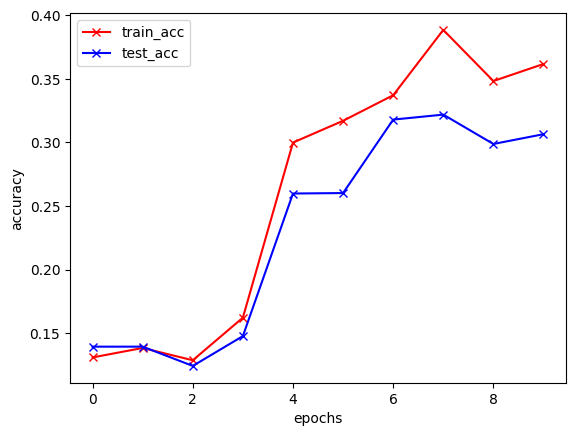

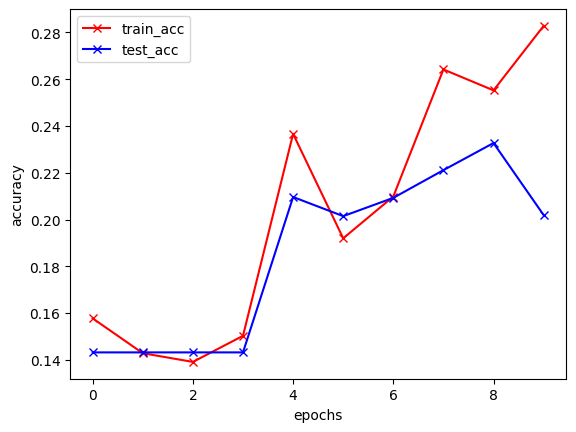

In [22]:
time = list(range(len(train_acc_1a)))

plt.plot(time, train_acc_1a, c='red', label='train_acc', marker='x')
plt.plot(time, test_acc_1a, c='blue', label='test_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

plt.plot(time, train_acc_1b, c='red', label='train_acc', marker='x')
plt.plot(time, test_acc_1b, c='blue', label='test_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

# Task III - ResNet Training on the DBI

## III.a

Model:

In [23]:
class Resnet18(ImageClassificationBase):
    def __init__(self):
        super().__init__()

        self.network = models.resnet18(pretrained=False)
        # Replace last layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Sequential(
            nn.Linear(num_ftrs, 7),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, xb):
        return self.network(xb)

Training:

In [24]:
# To switch datasets, change dataset path at the beginning and rerun all, including dataset initialization, preprocessing, etc.
model2 = Resnet18()
to_device(model2, device);

train_acc_2, val_acc_2, test_acc_2 = train_model(model2, train_dl, val_dl, test_dl, epochs=10, lr=0.035)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [1/10], Loss: 2.1444, Train Accuracy: 0.1399, Val Accuracy: 0.1111, Test Accuracy: 0.1513
Epoch [2/10], Loss: 1.7375, Train Accuracy: 0.1503, Val Accuracy: 0.1778, Test Accuracy: 0.1432
Epoch [3/10], Loss: 2.7668, Train Accuracy: 0.1548, Val Accuracy: 0.1111, Test Accuracy: 0.1513
Epoch [4/10], Loss: 1.7632, Train Accuracy: 0.1778, Val Accuracy: 0.2000, Test Accuracy: 0.1666
Epoch [5/10], Loss: 2.1074, Train Accuracy: 0.1920, Val Accuracy: 0.3111, Test Accuracy: 0.1704
Epoch [6/10], Loss: 1.4981, Train Accuracy: 0.2820, Val Accuracy: 0.2667, Test Accuracy: 0.2523
Epoch [7/10], Loss: 1.3929, Train Accuracy: 0.3802, Val Accuracy: 0.2667, Test Accuracy: 0.3686
Epoch [8/10], Loss: 1.1053, Train Accuracy: 0.4152, Val Accuracy: 0.3333, Test Accuracy: 0.4025
Epoch [9/10], Loss: 1.1563, Train Accuracy: 0.4851, Val Accuracy: 0.4000, Test Accuracy: 0.4264
Epoch [10/10], Loss: 1.5346, Train Accuracy: 0.5640, Val Accuracy: 0.4222, Test Accuracy: 0.4459


Plot results:

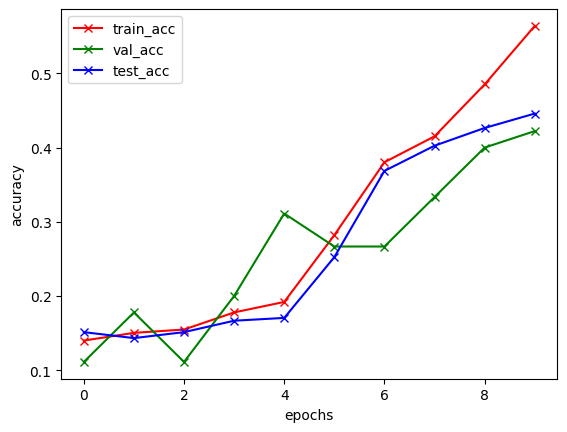

In [25]:
time = list(range(len(train_acc_2)))

plt.plot(time, train_acc_2, c='red', label='train_acc', marker='x')
plt.plot(time, val_acc_2, c='green', label='val_acc', marker='x')
plt.plot(time, test_acc_2, c='blue', label='test_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

## III.b

Test on Dataset SDD:

In [26]:
# Google Drive mount
# sdd_dataset = ImageFolder('/content/drive/My Drive/CSC/CSC420/Dataset/SDDsubset')
# local dir
sdd_dataset = ImageFolder('./Dataset/Dataset/SDDsubset')


sdd_test_dataset = DogBreedDataset(sdd_dataset, test_transform)
sdd_test_dl = DataLoader(sdd_test_dataset, batch_size*2, shuffle=False, pin_memory=True)
sdd_test_dl = DeviceDataLoader(sdd_test_dl, device)

# test on same model
dbi_test_acc = evaluate_accuracy(model2, test_dl)
sdd_test_acc = evaluate_accuracy(model2, sdd_test_dl)

print(f"DBI Test Accuracy: {dbi_test_acc:.4f}")
print(f"SDD Test Accuracy: {sdd_test_acc:.4f}")

DBI Test Accuracy: 0.4459
SDD Test Accuracy: 0.3330


Plot:

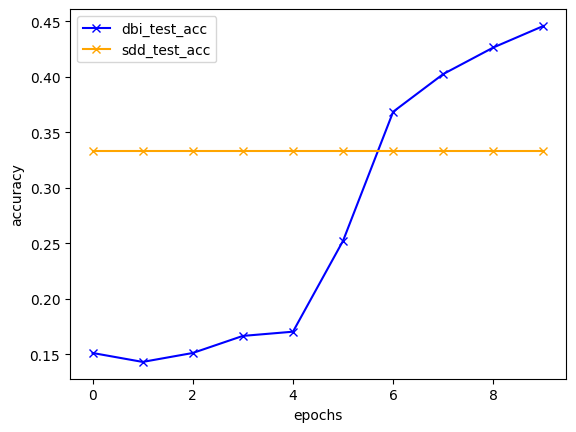

In [27]:
time = list(range(len(train_acc_2)))

# plt.plot(time, train_acc_2, c='red', label='train_acc', marker='x')
# plt.plot(time, val_acc_2, c='green', label='val_acc', marker='x')
plt.plot(time, test_acc_2, c='blue', label='dbi_test_acc', marker='x')
plt.plot(time, [sdd_test_acc] * 10, c='orange', label='sdd_test_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

# Task IV - Fine-tuning on the DBI

Model:

In [28]:
class FineTuneModel(ImageClassificationBase):
    def __init__(self, model_name):
        super().__init__()
        if model_name == 'resnet18':
            self.model = models.resnet18(pretrained=True)
        elif model_name == 'resnet34':
            self.model = models.resnet34(pretrained=True)
        elif model_name == 'resnext32':
            # Using resnext50_32x4d as per piazza post @126
            self.model = models.resnext50_32x4d(pretrained=True)
        else:
            raise ValueError("Unsupported model name")

        # Replace the final FNN
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Linear(num_ftrs, 7),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        return self.model(x)

Training:

In [29]:
# train on DBI
model3_resnet18 = FineTuneModel('resnet18')
model3_resnet34 = FineTuneModel('resnet34')
model3_resnext32 = FineTuneModel('resnext32')
to_device(model3_resnet18, device);
to_device(model3_resnet34, device);
to_device(model3_resnext32, device);

train_acc_3_resnet18, val_acc_3_resnet18, test_acc_3_resnet18 = train_model(model3_resnet18, train_dl, val_dl, test_dl, epochs=10, lr=0.0005)
train_acc_3_resnet34, val_acc_3_resnet34, test_acc_3_resnet34 = train_model(model3_resnet34, train_dl, val_dl, test_dl, epochs=10, lr=0.0005)
train_acc_3_resnext32, val_acc_3_resnext32, test_acc_3_resnext32 = train_model(model3_resnext32, train_dl, val_dl, test_dl, epochs=10, lr=0.0005)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloadi

Epoch [1/10], Loss: 2.1328, Train Accuracy: 0.1771, Val Accuracy: 0.2444, Test Accuracy: 0.1511
Epoch [2/10], Loss: 1.8912, Train Accuracy: 0.2842, Val Accuracy: 0.3556, Test Accuracy: 0.2516
Epoch [3/10], Loss: 1.4113, Train Accuracy: 0.5193, Val Accuracy: 0.4889, Test Accuracy: 0.4612
Epoch [4/10], Loss: 1.1879, Train Accuracy: 0.7507, Val Accuracy: 0.6444, Test Accuracy: 0.6590
Epoch [5/10], Loss: 0.8951, Train Accuracy: 0.8854, Val Accuracy: 0.8000, Test Accuracy: 0.8136
Epoch [6/10], Loss: 0.8794, Train Accuracy: 0.9405, Val Accuracy: 0.8222, Test Accuracy: 0.8719
Epoch [7/10], Loss: 0.9185, Train Accuracy: 0.9293, Val Accuracy: 0.8444, Test Accuracy: 0.8835
Epoch [8/10], Loss: 0.8024, Train Accuracy: 0.9501, Val Accuracy: 0.8889, Test Accuracy: 0.8796
Epoch [9/10], Loss: 0.7281, Train Accuracy: 0.9435, Val Accuracy: 0.8889, Test Accuracy: 0.8873
Epoch [10/10], Loss: 0.6769, Train Accuracy: 0.9494, Val Accuracy: 0.8889, Test Accuracy: 0.8912
Epoch [1/10], Loss: 2.1671, Train Accur

Testing results:

In [30]:
# test on DBI, SDD
dbi_test_3_resnet18_acc = evaluate_accuracy(model3_resnet18, test_dl)
sdd_test_3_resnet18_acc = evaluate_accuracy(model3_resnet18, sdd_test_dl)
dbi_test_3_resnet34_acc = evaluate_accuracy(model3_resnet34, test_dl)
sdd_test_3_resnet34_acc = evaluate_accuracy(model3_resnet34, sdd_test_dl)
dbi_test_3_resnext32_acc = evaluate_accuracy(model3_resnext32, test_dl)
sdd_test_3_resnext32_acc = evaluate_accuracy(model3_resnext32, sdd_test_dl)
print(f"resnet18 DBI Test Accuracy: {dbi_test_3_resnet18_acc:.4f}")
print(f"resnet18 SDD Test Accuracy: {sdd_test_3_resnet18_acc:.4f}")
print(f"resnet34 DBI Test Accuracy: {dbi_test_3_resnet34_acc:.4f}")
print(f"resnet34 SDD Test Accuracy: {sdd_test_3_resnet34_acc:.4f}")
print(f"resnext32 DBI Test Accuracy: {dbi_test_3_resnext32_acc:.4f}")
print(f"resnext32 SDD Test Accuracy: {sdd_test_3_resnext32_acc:.4f}")

resnet18 DBI Test Accuracy: 0.8912
resnet18 SDD Test Accuracy: 0.7612
resnet34 DBI Test Accuracy: 0.9341
resnet34 SDD Test Accuracy: 0.8446
resnext32 DBI Test Accuracy: 0.9845
resnext32 SDD Test Accuracy: 0.9385


Plot:

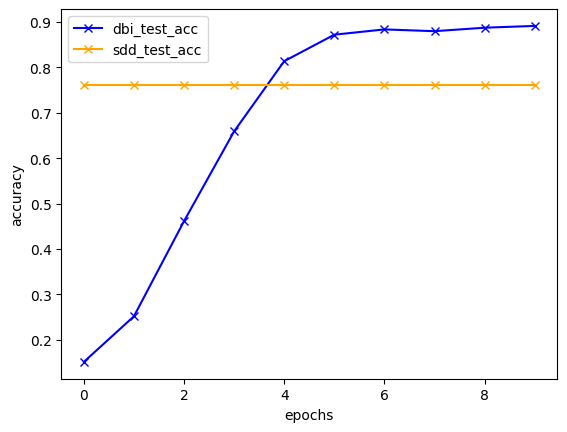

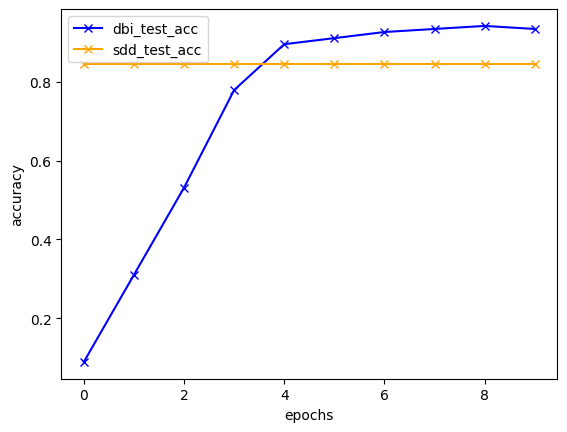

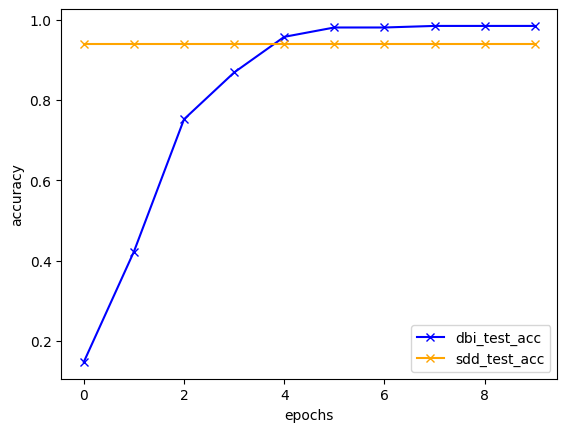

In [31]:
time = list(range(len(test_acc_3_resnet18)))

# resnet18
plt.plot(time, test_acc_3_resnet18, c='blue', label='dbi_test_acc', marker='x')
plt.plot(time, [sdd_test_3_resnet18_acc] * 10, c='orange', label='sdd_test_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

# resnet34
plt.plot(time, test_acc_3_resnet34, c='blue', label='dbi_test_acc', marker='x')
plt.plot(time, [sdd_test_3_resnet34_acc] * 10, c='orange', label='sdd_test_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

# resnext32
plt.plot(time, test_acc_3_resnext32, c='blue', label='dbi_test_acc', marker='x')
plt.plot(time, [sdd_test_3_resnext32_acc] * 10, c='orange', label='sdd_test_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

# Task V - Dataset classification

Dataset:

In [32]:
data_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# Google Drive mount
# dataset = ImageFolder('/content/drive/My Drive/CSC/CSC420/Dataset', transform=data_transform)
# local dir
dataset = ImageFolder('./Dataset/Dataset', transform=data_transform)

dataset_size = len(dataset)
test_pct = 0.3
test_size = int(dataset_size * test_pct)
val_pct = 0.1
val_size = int((dataset_size - test_size) * val_pct)
train_size = dataset_size - test_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

train_dl = DataLoader(train_ds, batch_size*2, shuffle=True, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size*2, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size*2, pin_memory=True)

train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
test_dl = DeviceDataLoader(test_dl, device)


Model:

In [33]:
class DatasetClassifier(ImageClassificationBase):
    def __init__(self, pretrained=True):
        super().__init__()
        self.network = models.resnext50_32x4d(pretrained=True)
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Sequential(
            nn.Linear(num_ftrs, 2),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        return self.network(x)

Training:

In [34]:
model4 = DatasetClassifier()
to_device(model4, device);

train_acc_4, val_acc_4, test_acc_4 = train_model(model4, train_dl, val_dl, test_dl, epochs=10, lr=0.0005)

Epoch [1/10], Loss: 0.6413, Train Accuracy: 0.6658, Val Accuracy: 0.8398, Test Accuracy: 0.6294
Epoch [2/10], Loss: 0.7262, Train Accuracy: 0.6674, Val Accuracy: 0.8359, Test Accuracy: 0.6341
Epoch [3/10], Loss: 0.4694, Train Accuracy: 0.6819, Val Accuracy: 0.8477, Test Accuracy: 0.6403
Epoch [4/10], Loss: 0.5841, Train Accuracy: 0.7006, Val Accuracy: 0.8555, Test Accuracy: 0.6482
Epoch [5/10], Loss: 0.5371, Train Accuracy: 0.7436, Val Accuracy: 0.8750, Test Accuracy: 0.6935
Epoch [6/10], Loss: 0.5536, Train Accuracy: 0.7834, Val Accuracy: 0.8984, Test Accuracy: 0.7366
Epoch [7/10], Loss: 0.4335, Train Accuracy: 0.8249, Val Accuracy: 0.9258, Test Accuracy: 0.7811
Epoch [8/10], Loss: 0.3519, Train Accuracy: 0.8349, Val Accuracy: 0.9297, Test Accuracy: 0.8037
Epoch [9/10], Loss: 0.3978, Train Accuracy: 0.8381, Val Accuracy: 0.9336, Test Accuracy: 0.8092
Epoch [10/10], Loss: 0.3935, Train Accuracy: 0.8351, Val Accuracy: 0.9336, Test Accuracy: 0.8147


Results:

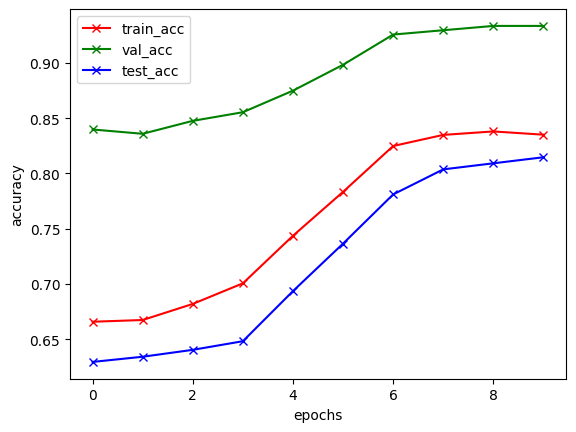

In [35]:
time = list(range(len(train_acc_4)))
plt.plot(time, train_acc_4, c='red', label='train_acc', marker='x')
plt.plot(time, val_acc_4, c='green', label='val_acc', marker='x')
plt.plot(time, test_acc_4, c='blue', label='test_acc', marker='x')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

# Task VI - How to improve performance on SDD?

## VI.a: Attraining time, we have access to the entire DBI dataset, but none of the SDD dataset. All we know is a high level description of SDD and its differences with DBI (similar to the answer you provided for Task I of this question).

1. More dataset augmentation. Since we know a high level description of SDD and its differences with DBI, we can simulate the known style or conditions of SDD using DBI.
2. Use better pre-trained model such as ResNeXt32, which could capture crutial features of the dataset itself, with less bias.

## VI.b: At training time, we have access to the entire DBI dataset and a small portion (e.g. 10%) of the SDD dataset.

1. Pre-train the model with DBI dataset for general feature understanding, then fine-tune the model using the 10% SDD dataset for better generalization on SDD dataset.

## VI.c: At training time, we have access to the entire DBI dataset and a small portion (e.g. 10%) of the SDD dataset but without the SDD labels for this subset.

1. Pre-train the model with DBI dataset. Use predictions of the model on the 10% SDD dataset as sudo-target for fine-tuning.

# Task VII - Discussion

Domain shift (from DBI to SDD) can cause reduced performance or biases in predictions.
In real-world applications, differences in the settings can lead to biased predictions and low accuracy.

To improve performance to adapt to the domain shift:
1. We can add Dropout layers within the model, which could improve generalization and reduce bias in real world setting.
2. We can Data Augmentation to simulate the setting after the domain shift for better representations of the new setting.
3. We can Use pre-trained models and apply fine-tuning, so that the model can focus on domain-specific differences, to gained a nuanced conprehension of features.